# Tree Segmentation - Single CHM Resolution (Dalponte 2016)

One CHM resolution, treetop detection (`lmf`) + crown delineation (`dalponte2016`), with diagnostics aimed at **over-segmentation** (one real tree split into several).

## Which CHM resolution? (literature summary)

**Recommendation: 0.5 m as the working resolution; keep 0.25 m only as a sensitivity check.**

- Orchard crowns here are ~4 m across (median equivalent diameter, see summary below). At 0.5 m a crown is ~8 cells wide: enough to see a rounded dome, too coarse to trace twigs and leaf gaps.
- Finer CHMs (0.1-0.25 m) from UAV LiDAR sometimes give the best detection in published comparisons ([ISPRS 2019 woodland study](https://isprs-archives.copernicus.org/articles/XLII-2-W13/657/2019/isprs-archives-XLII-2-W13-657-2019.pdf)), but crown edges get more irregular and every leaf cluster becomes a local maximum, so `lmf`/Dalponte need heavier smoothing or larger windows to avoid over-segmentation.
- Pits/gaps in fine-res CHMs from sparse returns are a classic cause of false treetops (pit-free CHM: Khosravipour et al. 2014).
- Dalponte's thresholds (`th_tree`, `th_seed`, `th_cr`) are **height-based and resolution-independent**; only `max_cr` depends on pixel size (lidR expects pixels, so this notebook converts metres to pixels).
- Your earlier arboretum sweep also favored a mid-resolution CHM (0.4 m).

Other refs: Dalponte & Coomes 2016 (MEE) for the algorithm; [Performance of ITS algorithms with UAV LiDAR (Drones 2024)](https://www.mdpi.com/2504-446X/8/12/772), where Dalponte2016 scored highest.

## What each R step does

| Step | Function | What it does |
|---|---|---|
| Smooth | `terra::focal(..., median)` | Replaces each cell by the median of its k x k neighbours; removes spikes/pits so one crown has one peak. |
| Treetops | `lidR::lmf(ws, hmin)` | Local Maximum Filter: a cell is a treetop if it is the highest within a `ws`-metre window and above `hmin`. **`ws` is the main driver of tree count**: too small -> over-segmentation, too big -> merged trees. |
| Crowns | `lidR::dalponte2016(chm, treetops, th_tree, th_seed, th_cr, max_cr)` | Region growing from each treetop (seed). A neighbouring cell joins the crown if its height is > `th_tree`; > `th_seed` x the **seed** height; > `th_cr` x the **mean crown height so far**; and it lies within `max_cr` (pixels) of the seed. |

Important consequence: Dalponte makes **exactly one crown per treetop**, so it cannot over-segment by itself. Over-segmentation comes from `lmf` placing two tops in one tree. The diagnostics below therefore test *pairs of touching crowns*: if the shorter top barely rises above the saddle between them (low **prominence**) and the tops are close, they are probably one tree.

## 1. Packages

In [1]:
# install.packages(c("terra", "sf", "lidR", "dplyr"))
suppressPackageStartupMessages({ library(terra); library(sf); library(lidR); library(dplyr) })
source("../scripts/segmentation_helpers.R")   # crown stats + over-segmentation diagnostics + plots

## 2. Configuration

In [2]:
cfg <- list(
  res        = "0.5m",   # CHM resolution to use: "0.5m" (recommended) or "0.25m" (sensitivity check)
  smooth_k   = 3,        # median smoothing kernel (cells). 3x3 @0.5 m = 1.5 m
  lmf_ws     = 5,      # local-maximum window (m): ~ half a typical crown diameter
  min_height = 2.0,      # ignore anything below this (m): ground, weeds, cover crop
  th_tree    = 2.0,      # Dalponte: min height of any crown cell (m)
  th_seed    = 0.45,     # Dalponte: cell must be > th_seed x seed height
  th_cr      = 0.55,     # Dalponte: cell must be > th_cr x mean crown height
  max_cr_m   = 10,       # Dalponte: max crown extent (m) - converted to pixels below
  # over-segmentation diagnostics
  os_min_prom = 1.0,     # shorter top must rise >= this (m) above the saddle, else the pair is suspect
  os_max_dist = 4.0,     # ...only checked for tops closer than this (m)
  os_min_area = 3.0,     # crowns smaller than this (m2) are flagged as slivers
  # ground-truth comparison
  match_max_dist = 4,  # max distance (m) between a surveyed tree and its segmented treetop
  outlier_m      = 5     # matches with |height error| >= this are also reported separately
)

## 3. Load CHM, smooth, detect treetops

In [3]:
# Paths are relative to the notebooks/ folder
chm_path <- sprintf("../../Rasters/bart_chm_%s_clipped.tif", cfg$res)
ground_path <- "../data/BR_Ground_Trees_with_app_measurements.xlsx"
out_dir  <- file.path("../outputs/Bartleson Tree Segmentation", paste0("dalponte_", cfg$res))
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

chm <- rast(chm_path)
res_m <- res(chm)[1]
cat("CHM:", basename(chm_path), "| resolution:", res_m, "m\n")

# Smooth + detect treetops (shared by both segmentation methods)
chm_smooth <- focal(chm, w = matrix(1, cfg$smooth_k, cfg$smooth_k), fun = median, na.rm = TRUE)
ttops <- locate_trees(chm_smooth, lmf(ws = cfg$lmf_ws, hmin = cfg$min_height))
ttops$height <- st_coordinates(ttops)[, "Z"]
cat("Treetops detected:", nrow(ttops), "\n")

CHM: bart_chm_0.5m_clipped.tif | resolution: 0.5 m
Treetops detected: 4256 


## 4. Dalponte crown delineation

In [4]:
max_cr_px <- ceiling(cfg$max_cr_m / res_m)       # lidR wants PIXELS, not metres
crowns <- dalponte2016(chm_smooth, ttops, th_tree = cfg$th_tree, th_seed = cfg$th_seed,
                       th_cr = cfg$th_cr, max_cr = max_cr_px)()
cat("max_cr =", max_cr_px, "pixels\n")

max_cr = 20 pixels


## 5. Over-segmentation diagnostics

Flags: **suspect pair** (touching, close, shallow saddle) and **small crown** (sliver).

In [6]:
polys <- crown_polygons(crowns, chm_smooth, ttops)
pairs <- adjacent_pairs(crowns, chm_smooth, ttops)
fl    <- flag_overseg(polys, pairs, cfg$os_min_prom, cfg$os_max_dist, cfg$os_min_area)
polys <- fl$polys; suspect_pairs <- fl$suspect_pairs

cat("Crowns:", nrow(polys), "| median crown diameter:", round(median(polys$diam_m), 2), "m\n")
print(table(polys$flag))
cat(sprintf("Suspect over-segmented pairs: %d  (%.1f%% of crowns involved)\n",
            nrow(suspect_pairs), 100 * mean(polys$in_suspect_pair)))

Crowns: 4256 | median crown diameter: 4.37 m

                  ok          small crown         suspect pair 
                3958                   23                  274 
suspect pair + small 
                   1 
Suspect over-segmented pairs: 139  (6.5% of crowns involved)


## 6. Visualization

Per footprint, left to right: CHM with treetops, crowns (random colours, black outline), and flags (red = suspect pair, red line joins the two tops; orange = sliver).

Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
"GDAL Message 1: Non-conformant content for record 1 in column esrignss_fixdatetime, 2026-08-18T15:43:18.0Z, successfully parsed"
Warning message in plot.sf(ttops, col = "red", add = TRUE, cex = 0.1):
"ignoring all but the first attribute"


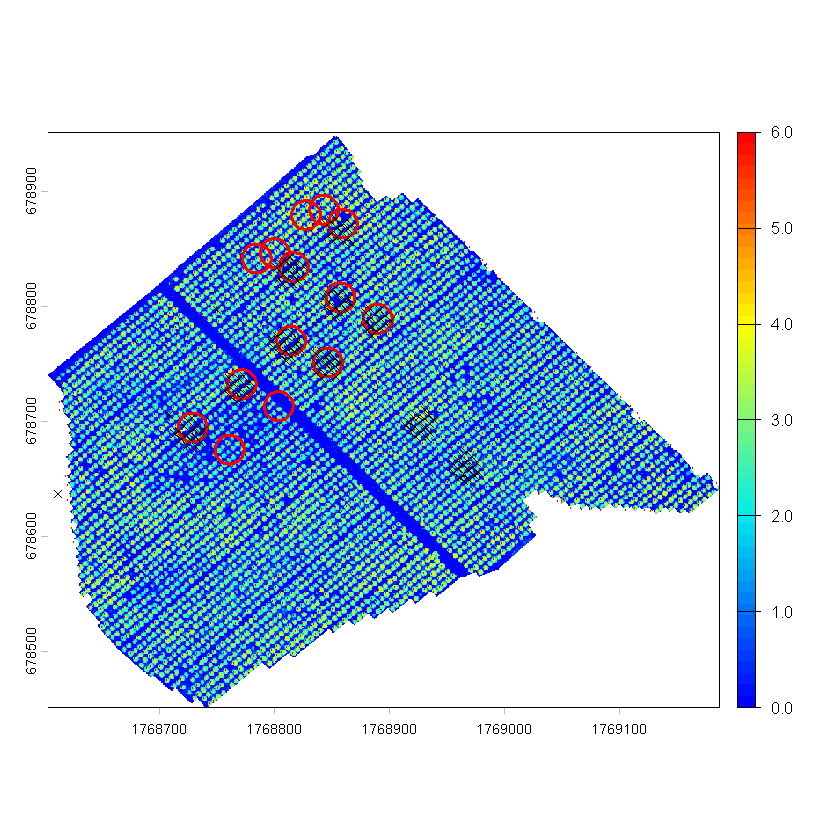

In [7]:
col <- height.colors(50)

footprints <- st_read("../../selected_v3_footprints_.gpkg", quiet = TRUE) |> st_transform(st_crs(chm))
ground     <- st_read("../../Rasters/BR_Ground_Trees.gpkg", quiet = TRUE) |> st_transform(st_crs(chm))

plot(chm, range = c(0, 6), col = col)
plot(ttops, col = "red", add = TRUE, cex = 0.1)
plot(st_geometry(footprints), border = "red", col = NA, lwd = 3, add = TRUE)  # thin outlines
plot(st_geometry(ground), pch = 4, col = "black", cex = 0.8, add = TRUE)          # pch 4 = x

In [ ]:
# Whole-scene map: crowns coloured by over-segmentation flag
options(repr.plot.width = 14, repr.plot.height = 12)
flag_cols <- c("ok" = "#cccccc", "small crown" = "#f4a300", "suspect pair" = "#e03131", "suspect pair + small" = "#7b0000")
plot(chm_smooth, col = gray.colors(50, 0.3, 1), legend = FALSE, main = "All crowns - flagged for possible over-segmentation")
plot(st_geometry(polys), col = adjustcolor(flag_cols[polys$flag], 0.7), border = NA, add = TRUE)
legend("topright", legend = names(flag_cols), fill = adjustcolor(flag_cols, 0.7), bg = "white")

In [ ]:
options(repr.plot.width = 24, repr.plot.height = 8)

# The 4 most over-segmented 30 m blocks in the scene: CHM+tops | crowns | flags
blk <- suspect_pairs |>
  mutate(bx = floor((xa + xb) / 2 / 30), by = floor((ya + yb) / 2 / 30)) |>
  count(bx, by, sort = TRUE) |> head(4)
for (k in seq_len(nrow(blk))) {
  w <- ext(blk$bx[k] * 30, (blk$bx[k] + 1) * 30, blk$by[k] * 30, (blk$by[k] + 1) * 30)
  plot_overseg_window(chm_smooth, polys, ttops, suspect_pairs, w,
                      title = sprintf("Block %d (%d suspect pairs)", k, blk$n[k]))
}

**Worst offenders:** the pairs with the shallowest saddle anywhere in the scene. If these look like one tree, increase `lmf_ws` or `smooth_k`; if they look like two trees, loosen `os_min_prom`.

In [ ]:
# The most likely over-segmentations in the whole scene (lowest prominence first)
worst <- suspect_pairs |> arrange(prominence) |> head(6)
for (k in seq_len(nrow(worst))) {
  xm <- (worst$xa[k] + worst$xb[k]) / 2; ym <- (worst$ya[k] + worst$yb[k]) / 2
  plot_overseg_window(chm_smooth, polys, ttops, suspect_pairs, ext(xm - 6, xm + 6, ym - 6, ym + 6),
                      title = sprintf("Pair %d-%d: prominence %.2f m, tops %.1f m apart",
                                      worst$a[k], worst$b[k], worst$prominence[k], worst$dist_m[k]))
}

## 7. Compare to ground-measured heights

Surveyed trees (`BR_Ground_Trees.gpkg`, `GT_Height`) are matched one-to-one to the nearest segmented treetop within `match_max_dist`. Rows tagged as tests (wind turbine, tall eucalyptus) are dropped. Two segmented heights are compared: the smoothed-CHM treetop height and the maximum raw-CHM value in the crown (smoothing lowers peaks).

In [8]:
ground  <- read_ground_trees(ground_path, st_crs(chm))
matched <- match_ground_trees(ground, ttops, polys, chm, cfg$match_max_dist)

cat(sprintf("\nMatched %d of %d surveyed trees within %.1f m (median distance %.2f m)\n",
            nrow(matched), nrow(ground), cfg$match_max_dist, median(matched$dist_m)))

metrics <- rbind(`smoothed treetop height` = height_metrics(matched$seg_height_m, matched$gt_height_m),
                 `raw CHM max in crown`    = height_metrics(matched$raw_max_m,    matched$gt_height_m))
cat("All matches:\n"); print(round(metrics, 3))

# Same, dropping gross mismatches (likely a wrong match or a bad field height, not segmentation error)
ok <- abs(matched$err_seg) < cfg$outlier_m
cat(sprintf("\nExcluding %d match(es) with |error| >= %.0f m:\n", sum(!ok), cfg$outlier_m))
print(round(rbind(`smoothed treetop height` = height_metrics(matched$seg_height_m[ok], matched$gt_height_m[ok]),
                  `raw CHM max in crown`    = height_metrics(matched$raw_max_m[ok],    matched$gt_height_m[ok])), 3))
cat("\nNote: R2 is weak evidence here - surveyed heights span only ~2.4-3.5 m.\n")

ground_tbl <- data.frame(
  ground_row = seq_len(nrow(ground)),
  label      = ground$Tree_Label,
  gt_x       = st_coordinates(ground)[, 1],
  gt_y       = st_coordinates(ground)[, 2],
  gt_height_m = ground$gt_height_m,
  gt_dbh      = ground$GT_DBH
)

comparison <- ground_tbl |>
  left_join(
    matched |> select(ground_row, seg_treeID = treeID, seg_x = xt, seg_y = yt, dist_m,
                      seg_height_m, raw_max_m, err_seg, err_raw),
                      # err_raw = the highest raw CHM value anywhere inside the whole crown polygon, which came from the smoothed segmentation
                      # err_seg = the segmented chm height minus the ground height, using the smoothed treetop height
    by = "ground_row"
  ) |>
    left_join(
    st_drop_geometry(polys) |> select(seg_treeID = treeID, crown_diam_m = diam_m, crown_area_m2 = area_m2),
    by = "seg_treeID"
  ) |>
  mutate(
    matched    = !is.na(seg_treeID),
    pct_err    = round(100 * err_seg / gt_height_m, 1),
    gross_miss = abs(err_seg) >= cfg$outlier_m
  ) |>
    mutate(
    gt_biomass    = 53.03 - 6.64 * gt_dbh + 0.53 * gt_dbh^2 - 0.01 * gt_dbh^3,
    drone_biomass = -1.64 + 6.73 * crown_diam_m + 2.87 * raw_max_m^2,
    biomass_diff  = drone_biomass - gt_biomass,
    biomass_pct   = round(100 * biomass_diff / gt_biomass, 1)
  ) |>
  select(label, gt_dbh, gt_height_m, seg_height_m, err_raw, gt_biomass, drone_biomass, biomass_diff, biomass_pct, crown_diam_m, crown_area_m2, gt_x, gt_y, seg_treeID, seg_x, seg_y, dist_m,
         err_seg, pct_err, raw_max_m, matched, gross_miss) |>
arrange(
    suppressWarnings(as.numeric(sub("\\..*", "", label))),   # part before the dot (e.g. 1, 2, 10)
    suppressWarnings(as.numeric(sub(".*\\.", "", label))),   # part after the dot
    label                                                    # non-numeric labels (e.g. "Phytech") last, alphabetical
  )


print(comparison, digits = 3)   # or View(comparison)
write.csv(comparison, file.path(out_dir, "ground_height_comparison.csv"), row.names = FALSE)


Matched 200 of 204 surveyed trees within 4.0 m (median distance 2.12 m)
All matches:
                          n  bias   MAE  RMSE    R2
smoothed treetop height 200 0.396 0.406 0.836 0.113
raw CHM max in crown    200 0.628 0.628 1.195 0.055

Excluding 1 match(es) with |error| >= 5 m:
                          n  bias   MAE  RMSE    R2
smoothed treetop height 199 0.346 0.356 0.402 0.686
raw CHM max in crown    199 0.576 0.576 0.911 0.137

Note: R2 is weak evidence here - surveyed heights span only ~2.4-3.5 m.
    label gt_dbh gt_height_m seg_height_m err_raw gt_biomass drone_biomass
1     1.1   16.5         2.7         3.06   0.540       42.8          57.4
2     1.2   16.7         3.0         2.96   0.131       43.4          57.6
3     1.3   19.0         3.0         3.45   0.570       49.6          67.2
4     1.4   20.8         2.5         3.24   0.920       54.2          60.3
5     1.5   18.2         2.9         2.95   0.479       47.5          60.0
6     1.6   17.7         2.6       

# Print images of all of the matched Drone Height locations to Arrow Coordinates of Trees
this could potenitally get updated to just show the ones that did not get matched? with over 200 trees this is super long and not really needed unless troubleshooting what the proper distance looking for matching should be

In [ ]:
half <- 6            # half-width of each zoom window (m)
n_per_page <- 20     # panels per figure (4 x 5)
cmp_plot <- comparison[!is.na(comparison$gt_x), ]

for (pg in split(seq_len(nrow(cmp_plot)), ceiling(seq_len(nrow(cmp_plot)) / n_per_page))) {
  options(repr.plot.width = 20, repr.plot.height = 16)
  par(mfrow = c(4, 5), mar = c(2, 2, 3, 1))
  for (i in pg) {
    r <- cmp_plot[i, ]
    e <- ext(r$gt_x - half, r$gt_x + half, r$gt_y - half, r$gt_y + half)
    bb <- st_bbox(c(xmin = xmin(e), xmax = xmax(e), ymin = ymin(e), ymax = ymax(e)), crs = st_crs(ttops))

    ttl <- if (r$matched) sprintf("%s | %.1f m apart\nGT %.1f m vs seg %.1f m", r$label, r$dist_m, r$gt_height_m, r$seg_height_m)
           else           sprintf("%s | NO MATCH within %.1f m\nGT %.1f m", r$label, cfg$match_max_dist, r$gt_height_m)
    plot(crop(chm_smooth, e), col = height.colors(50), range = c(0, 6), legend = FALSE, main = ttl, cex.main = 0.9)

    # other treetops in the window (faint), matched crown outline
    tt_w <- ttops[st_intersects(ttops, st_as_sfc(bb), sparse = FALSE)[, 1], ]
    plot(st_geometry(tt_w), add = TRUE, pch = 3, col = adjustcolor("blue", 0.35))
    if (r$matched) {
      plot(st_geometry(polys[polys$treeID == r$seg_treeID, ]), border = "white", col = NA, lwd = 2, add = TRUE)
      segments(r$gt_x, r$gt_y, r$seg_x, r$seg_y, col = "black", lty = 2)
      points(r$seg_x, r$seg_y, pch = 3, col = "blue", lwd = 3, cex = 2)      # segmented treetop
    }
    points(r$gt_x, r$gt_y, pch = 4, col = "red", lwd = 3, cex = 2)        # ground-measured location
  }
  par(mfrow = c(1, 1))
}

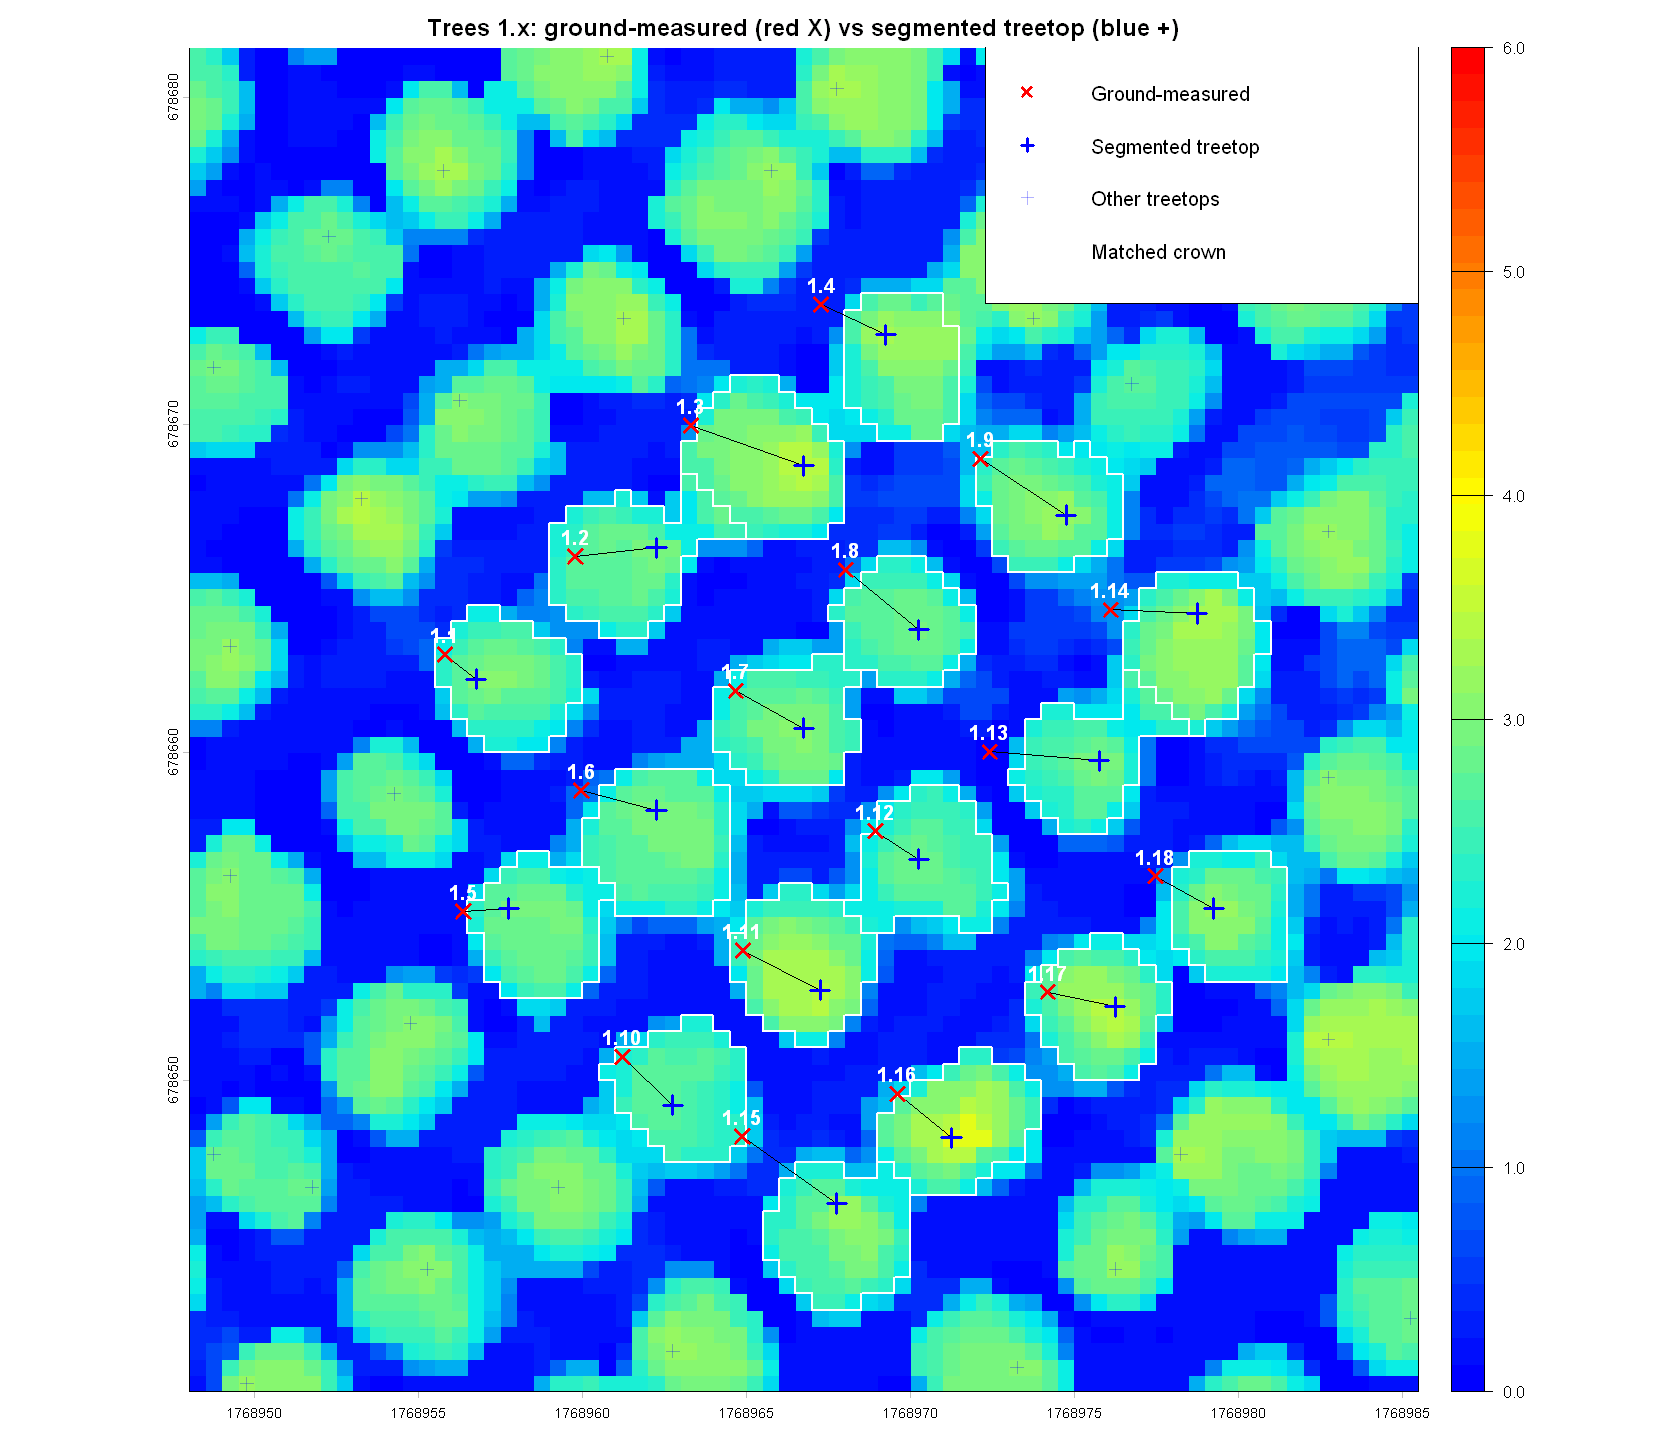

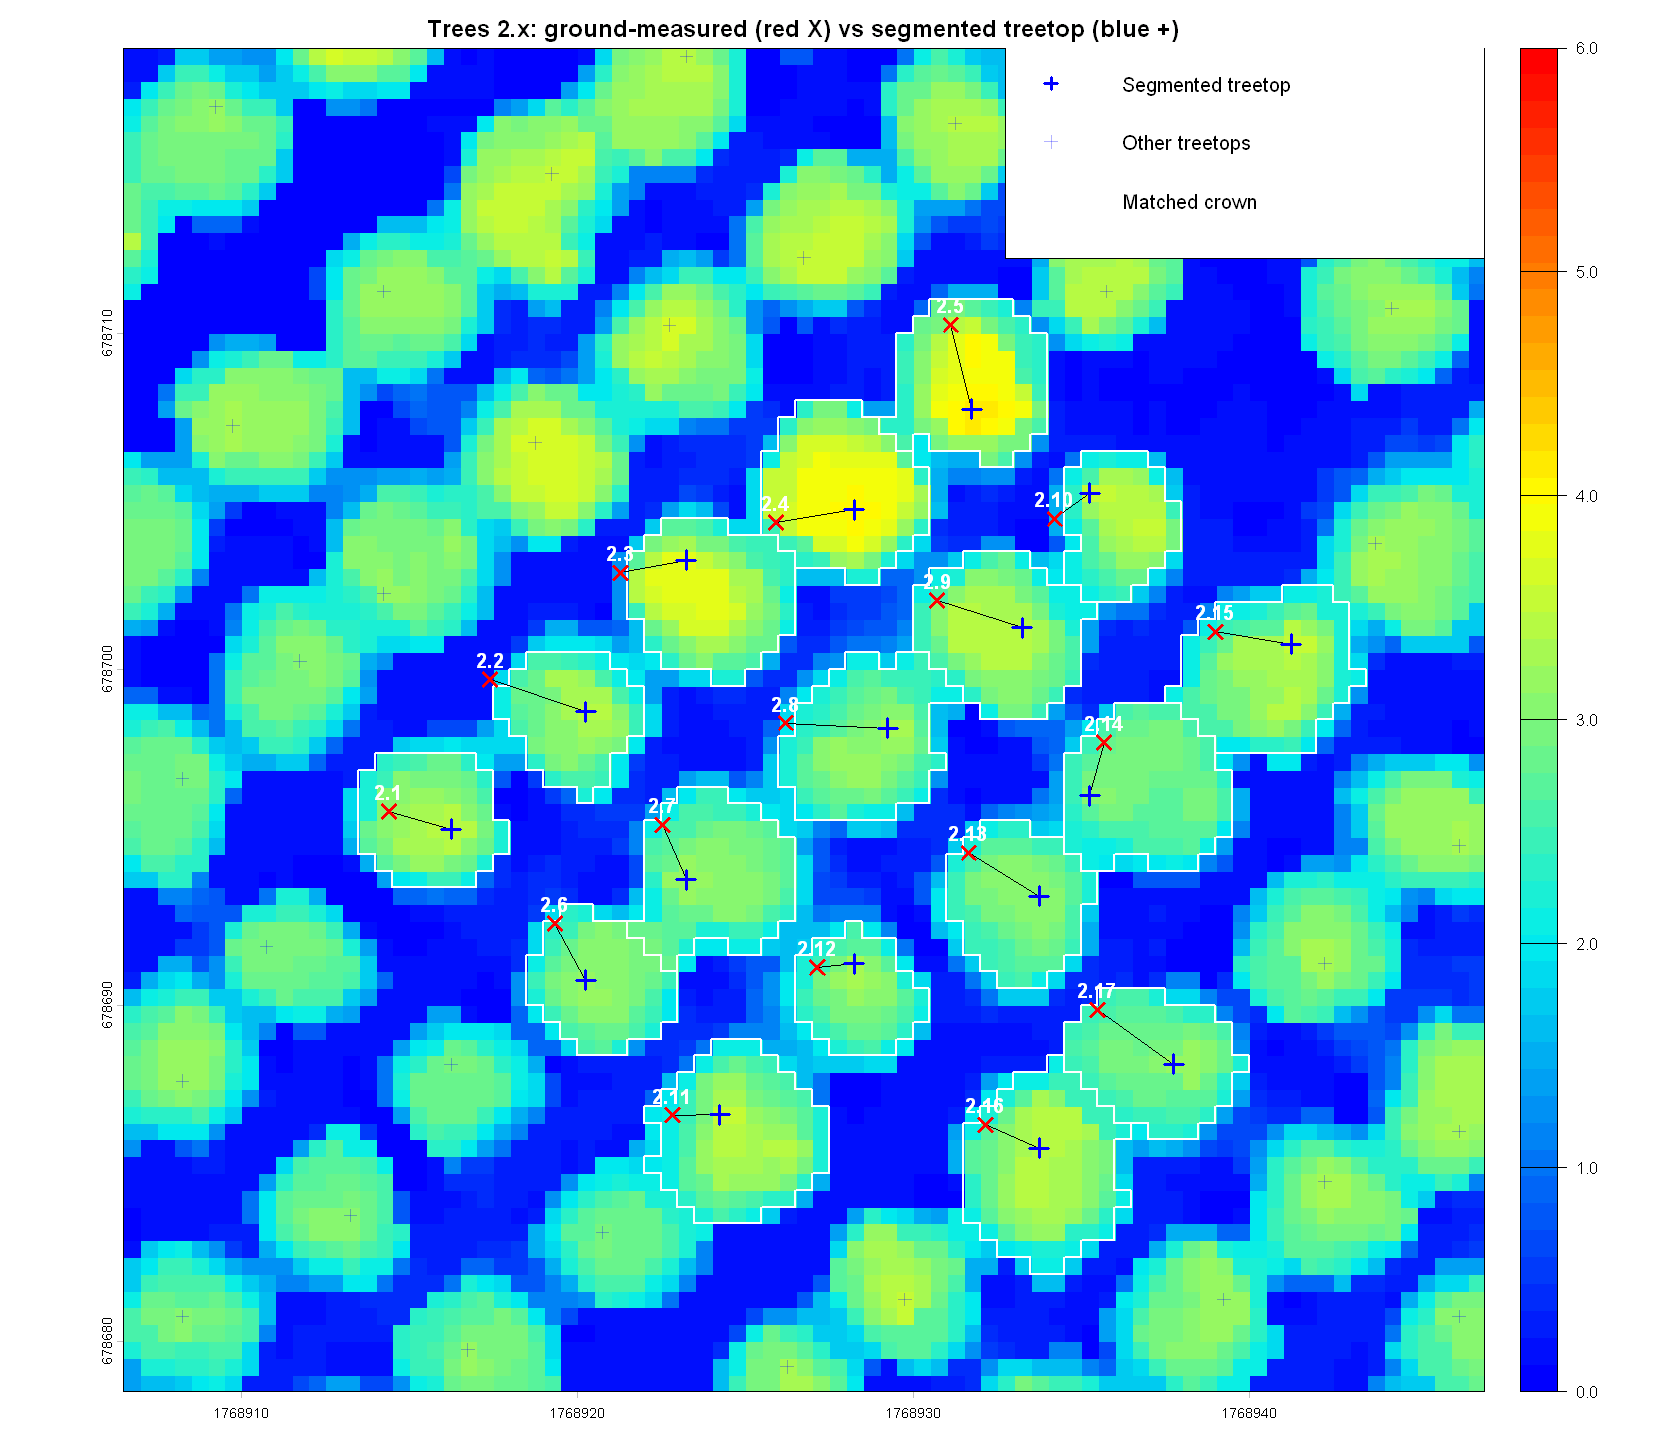

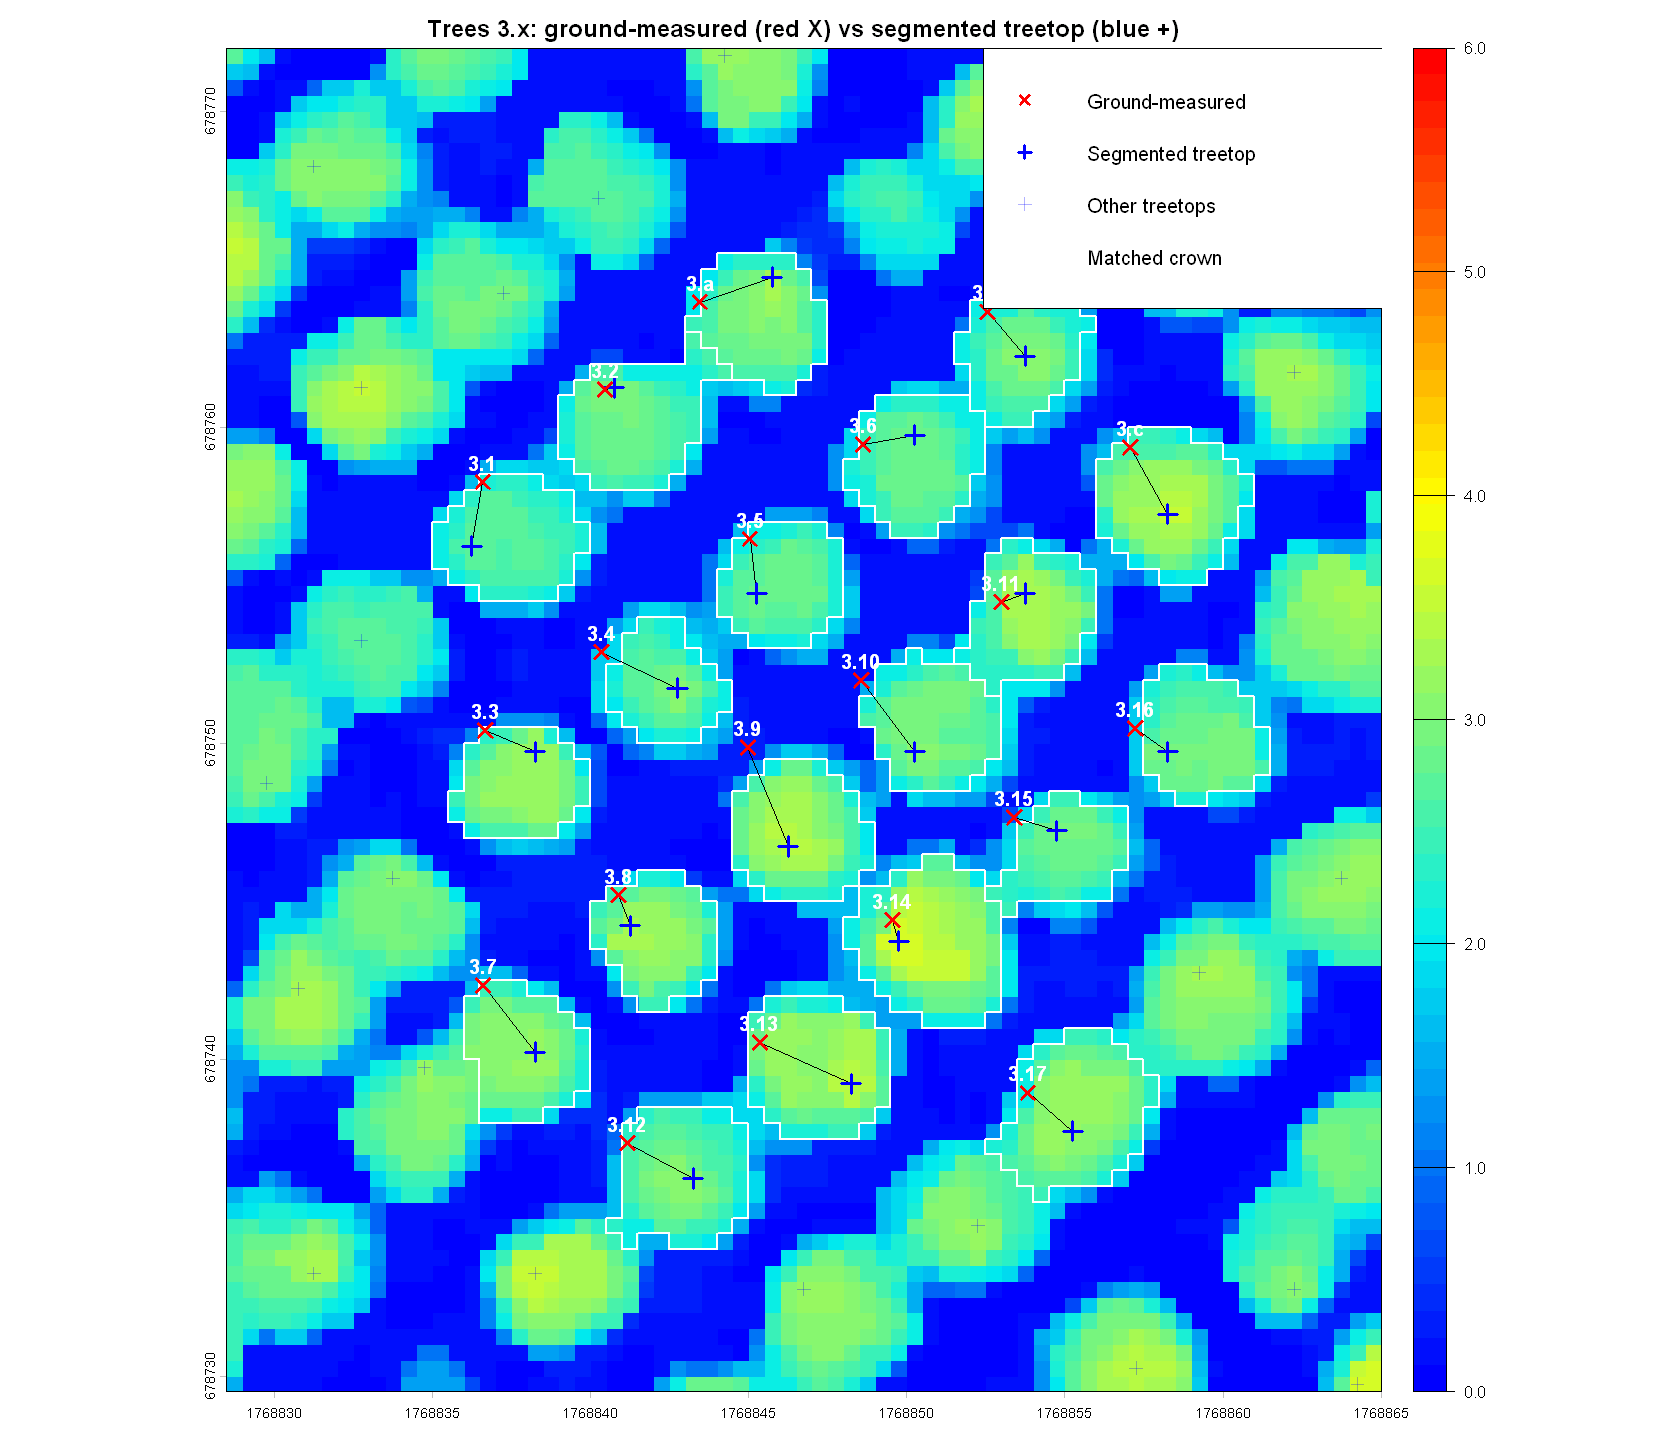

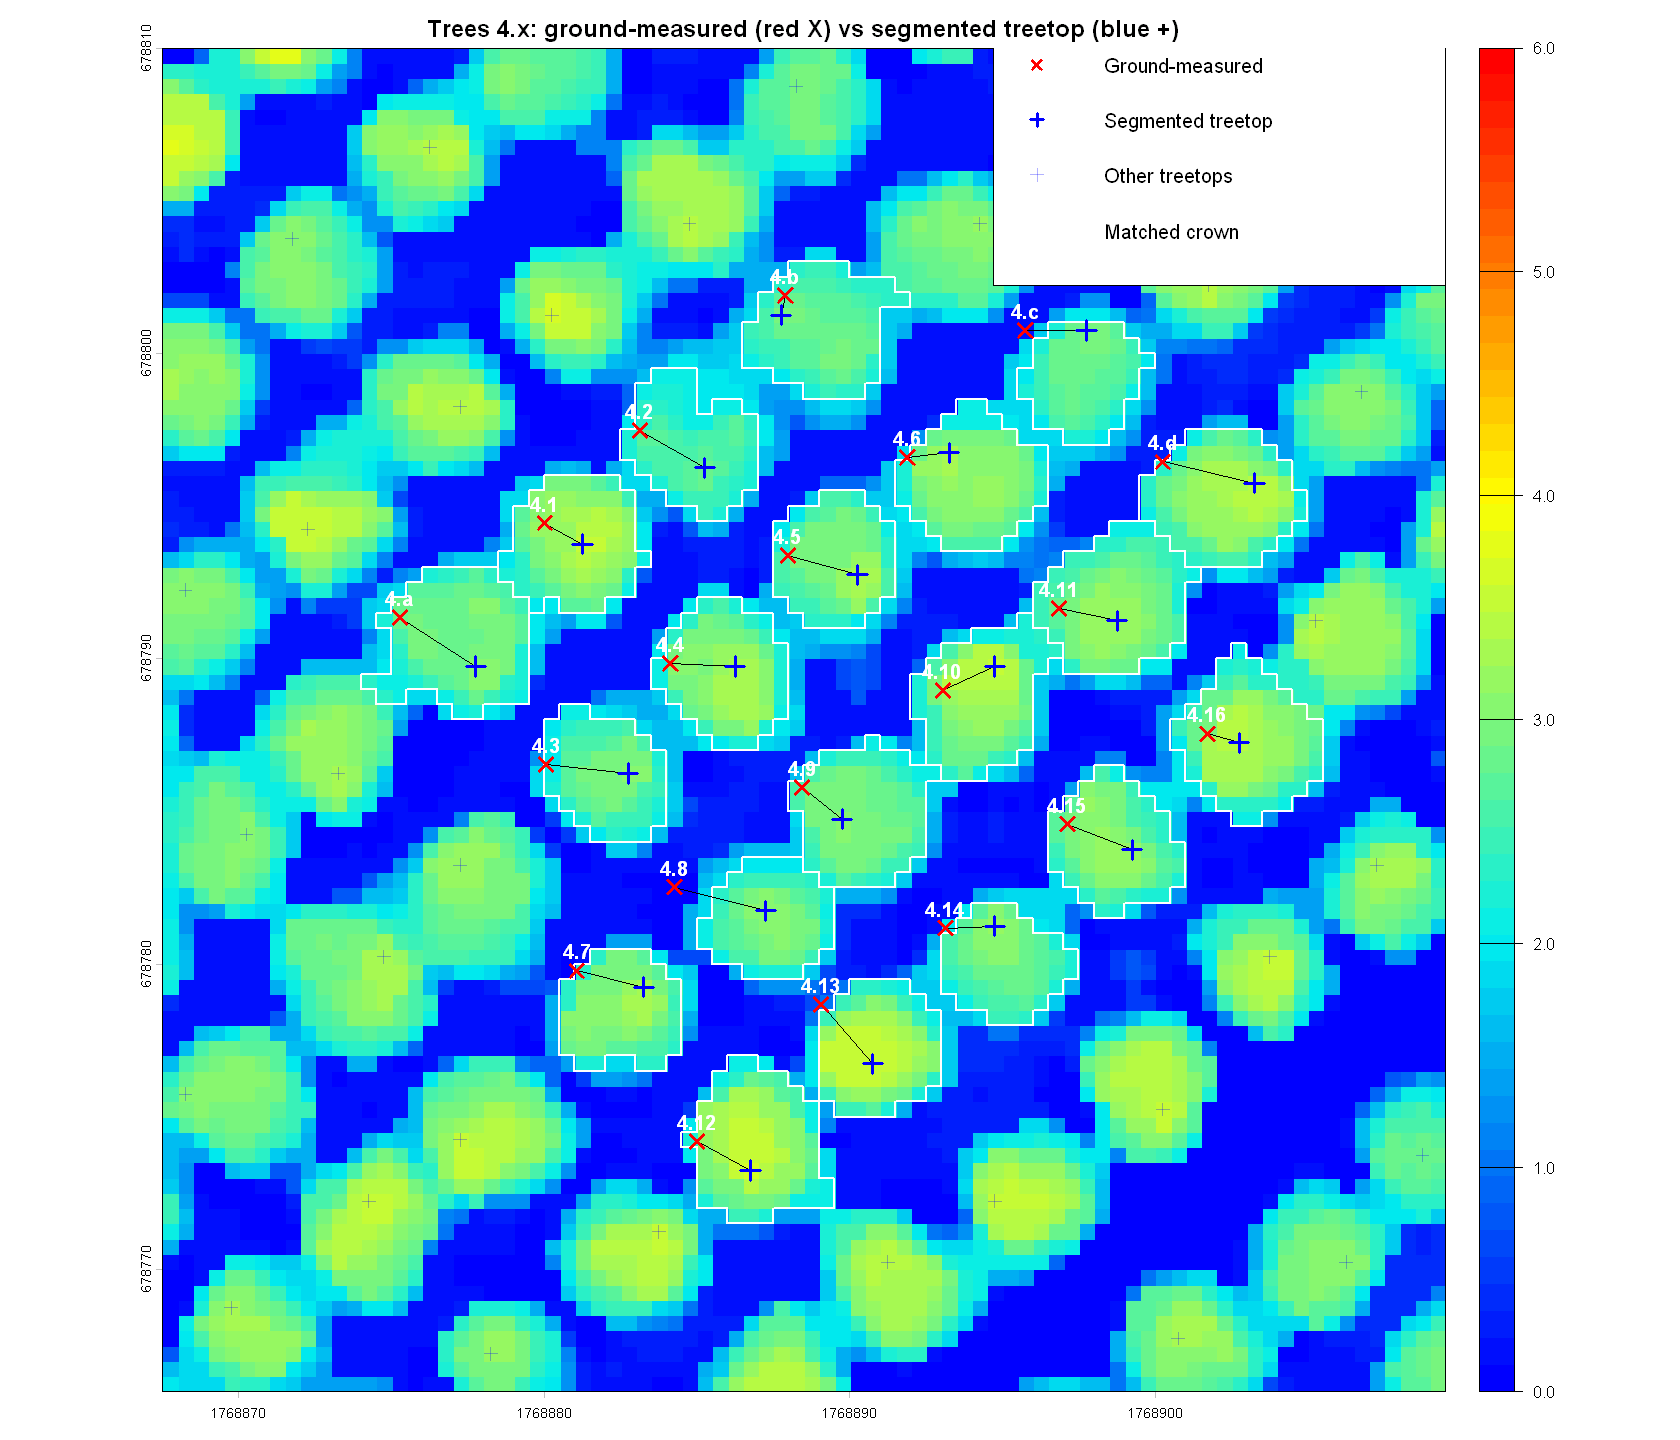

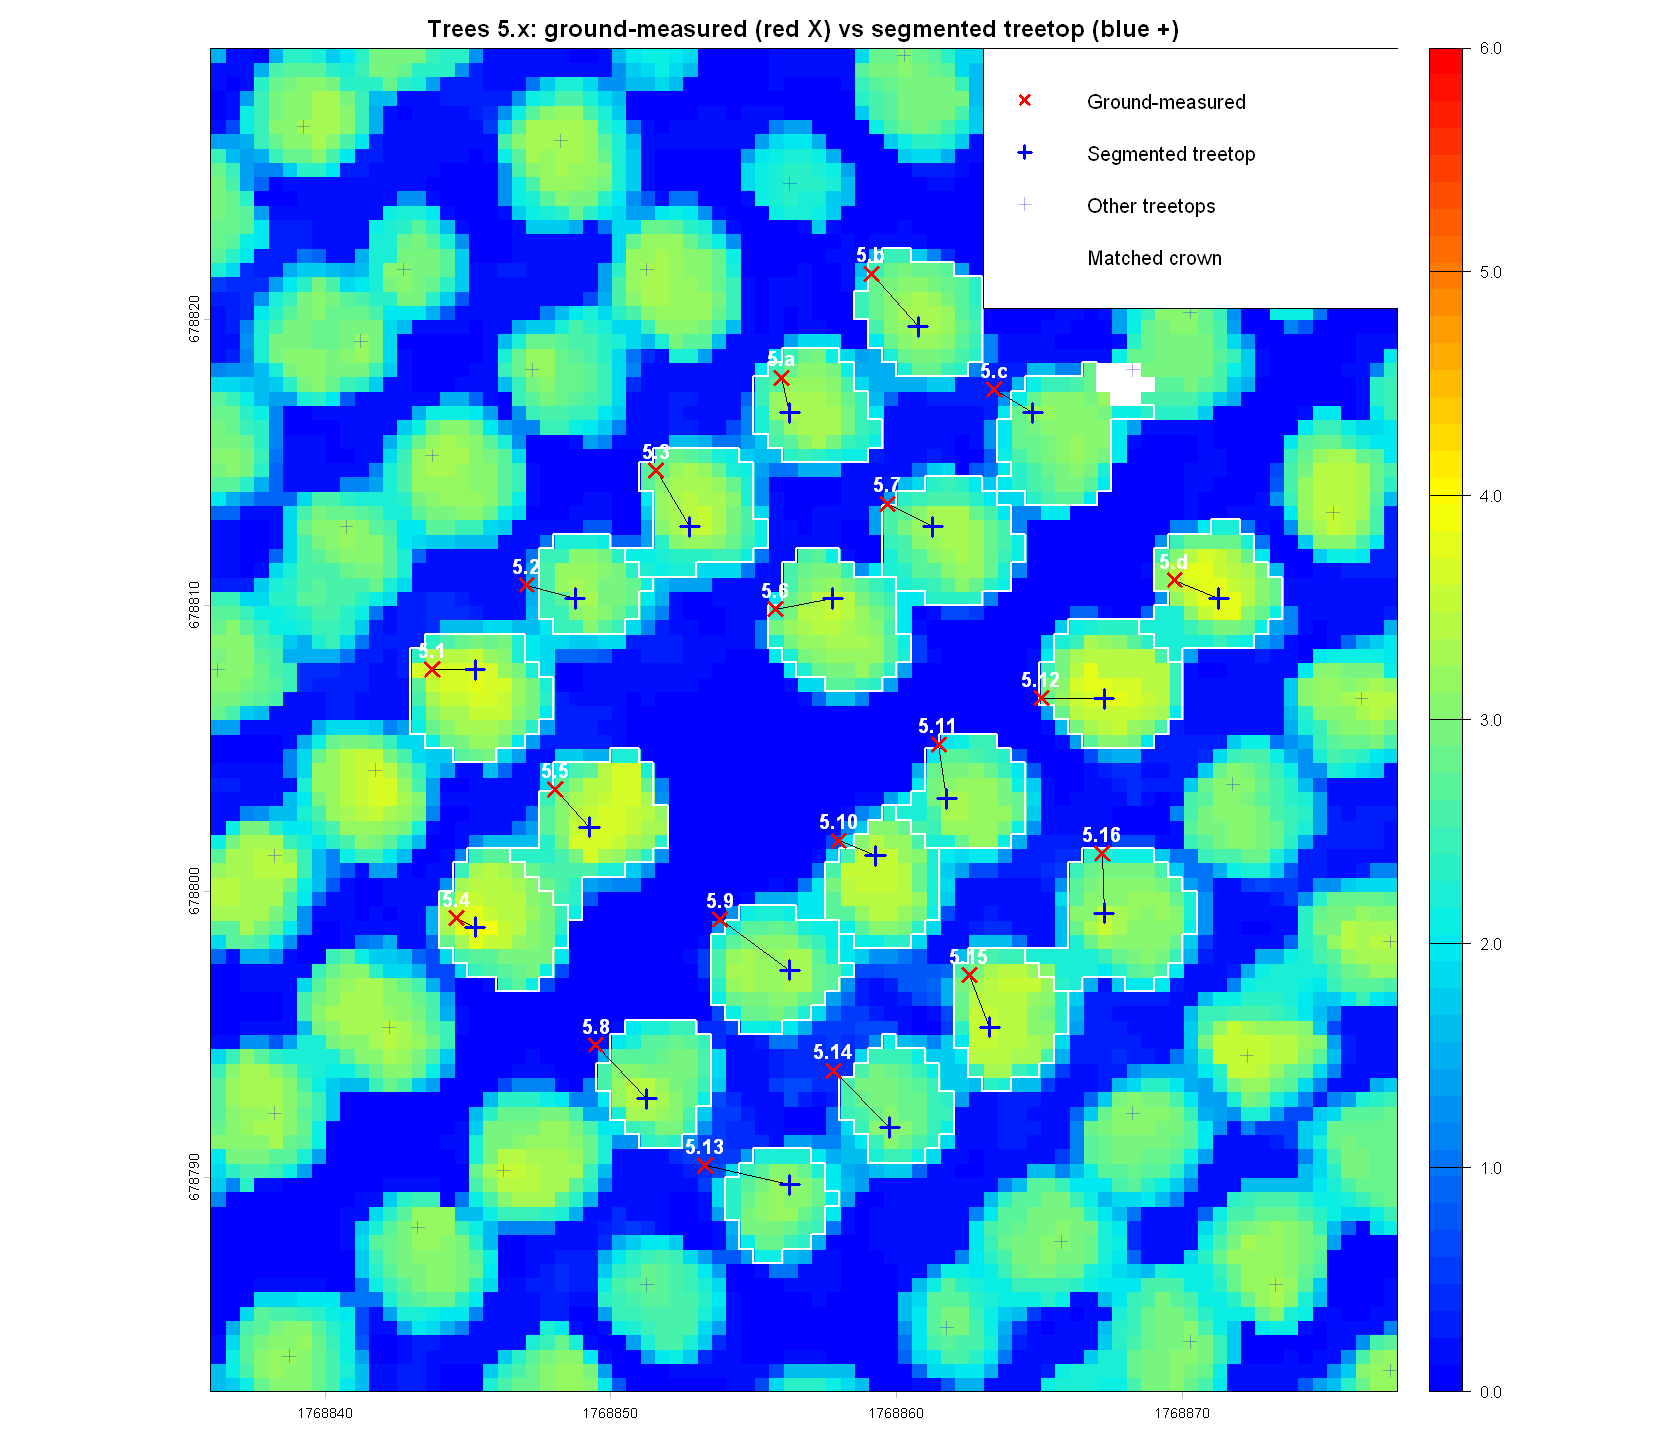

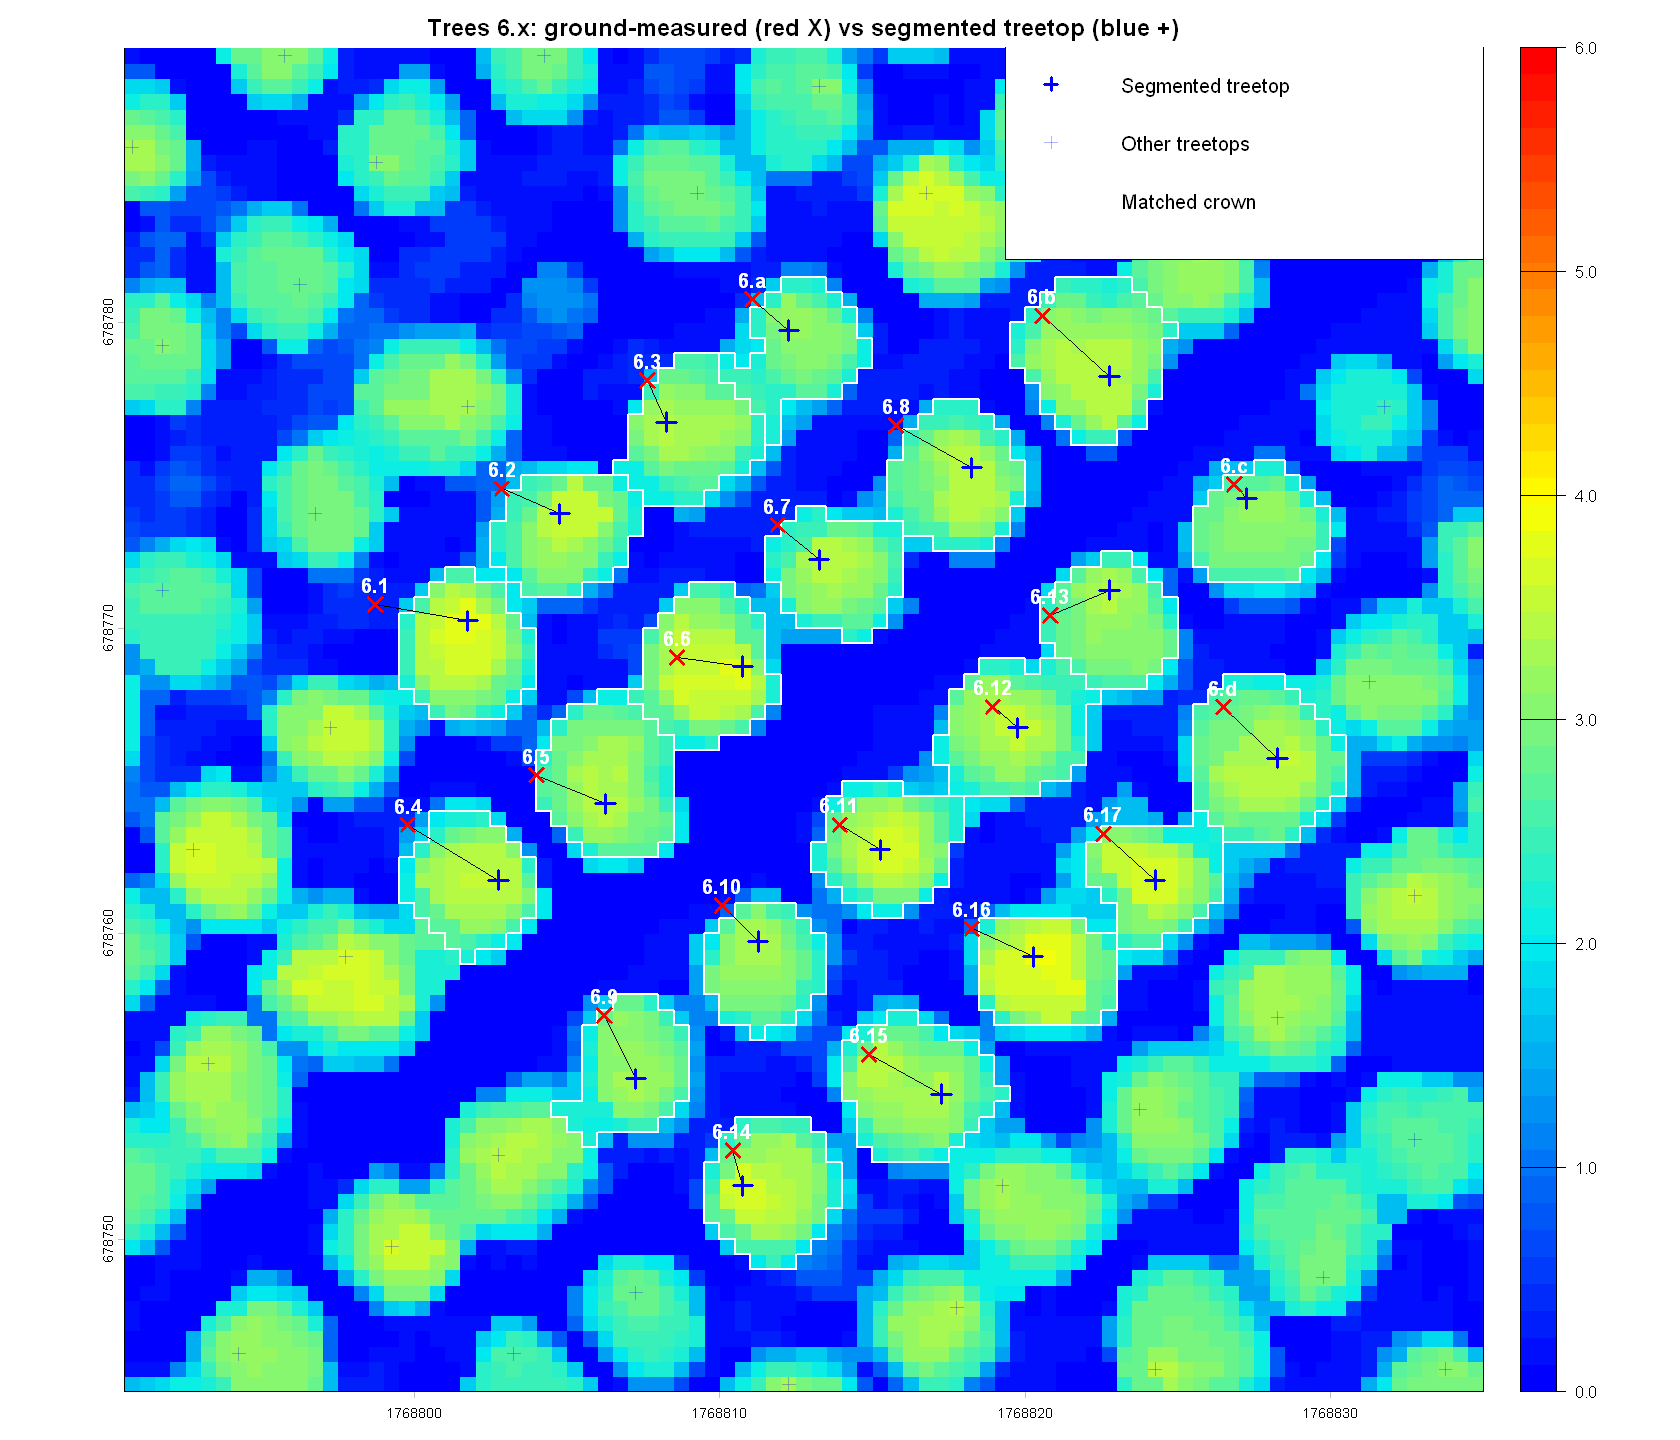

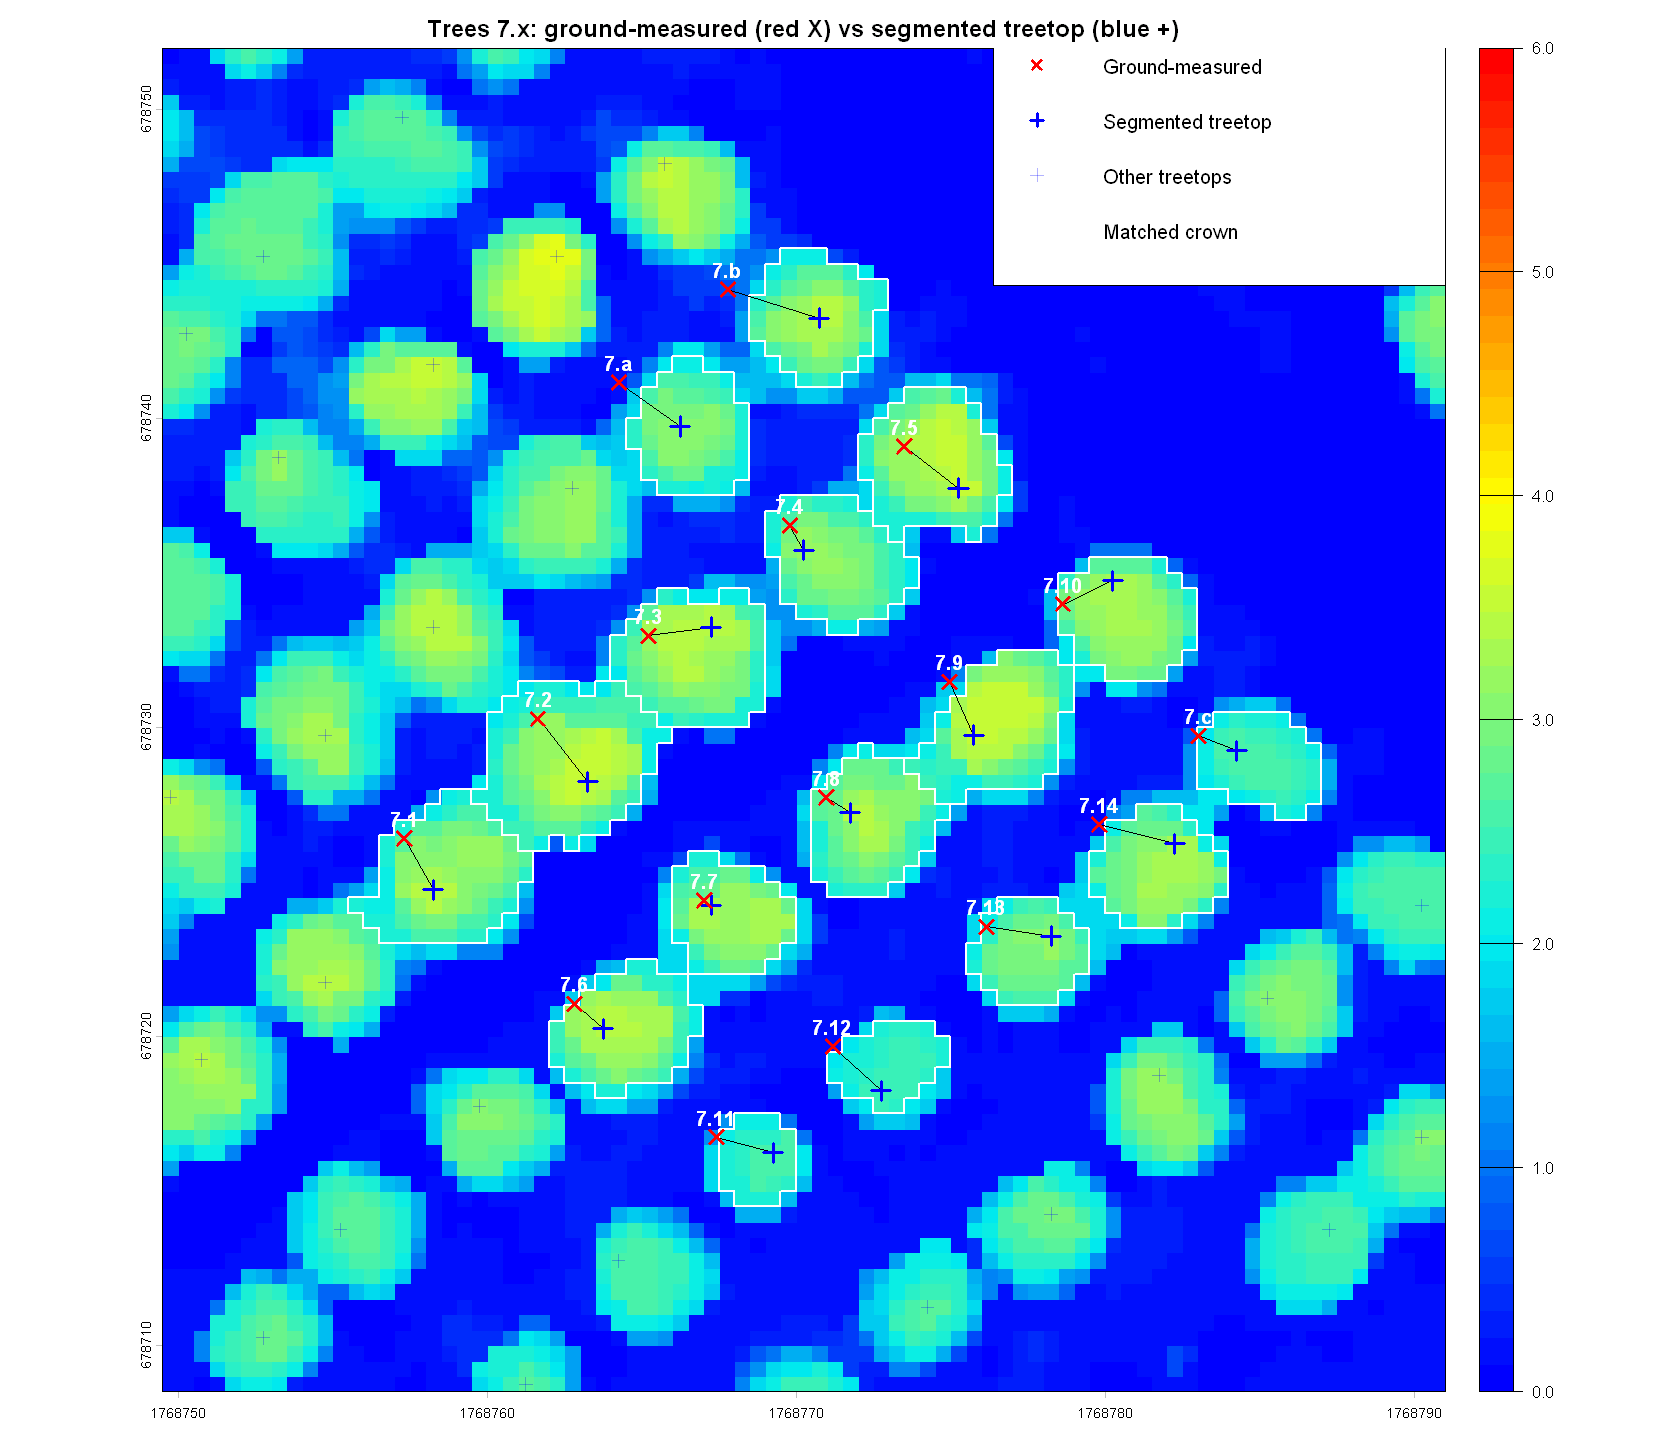

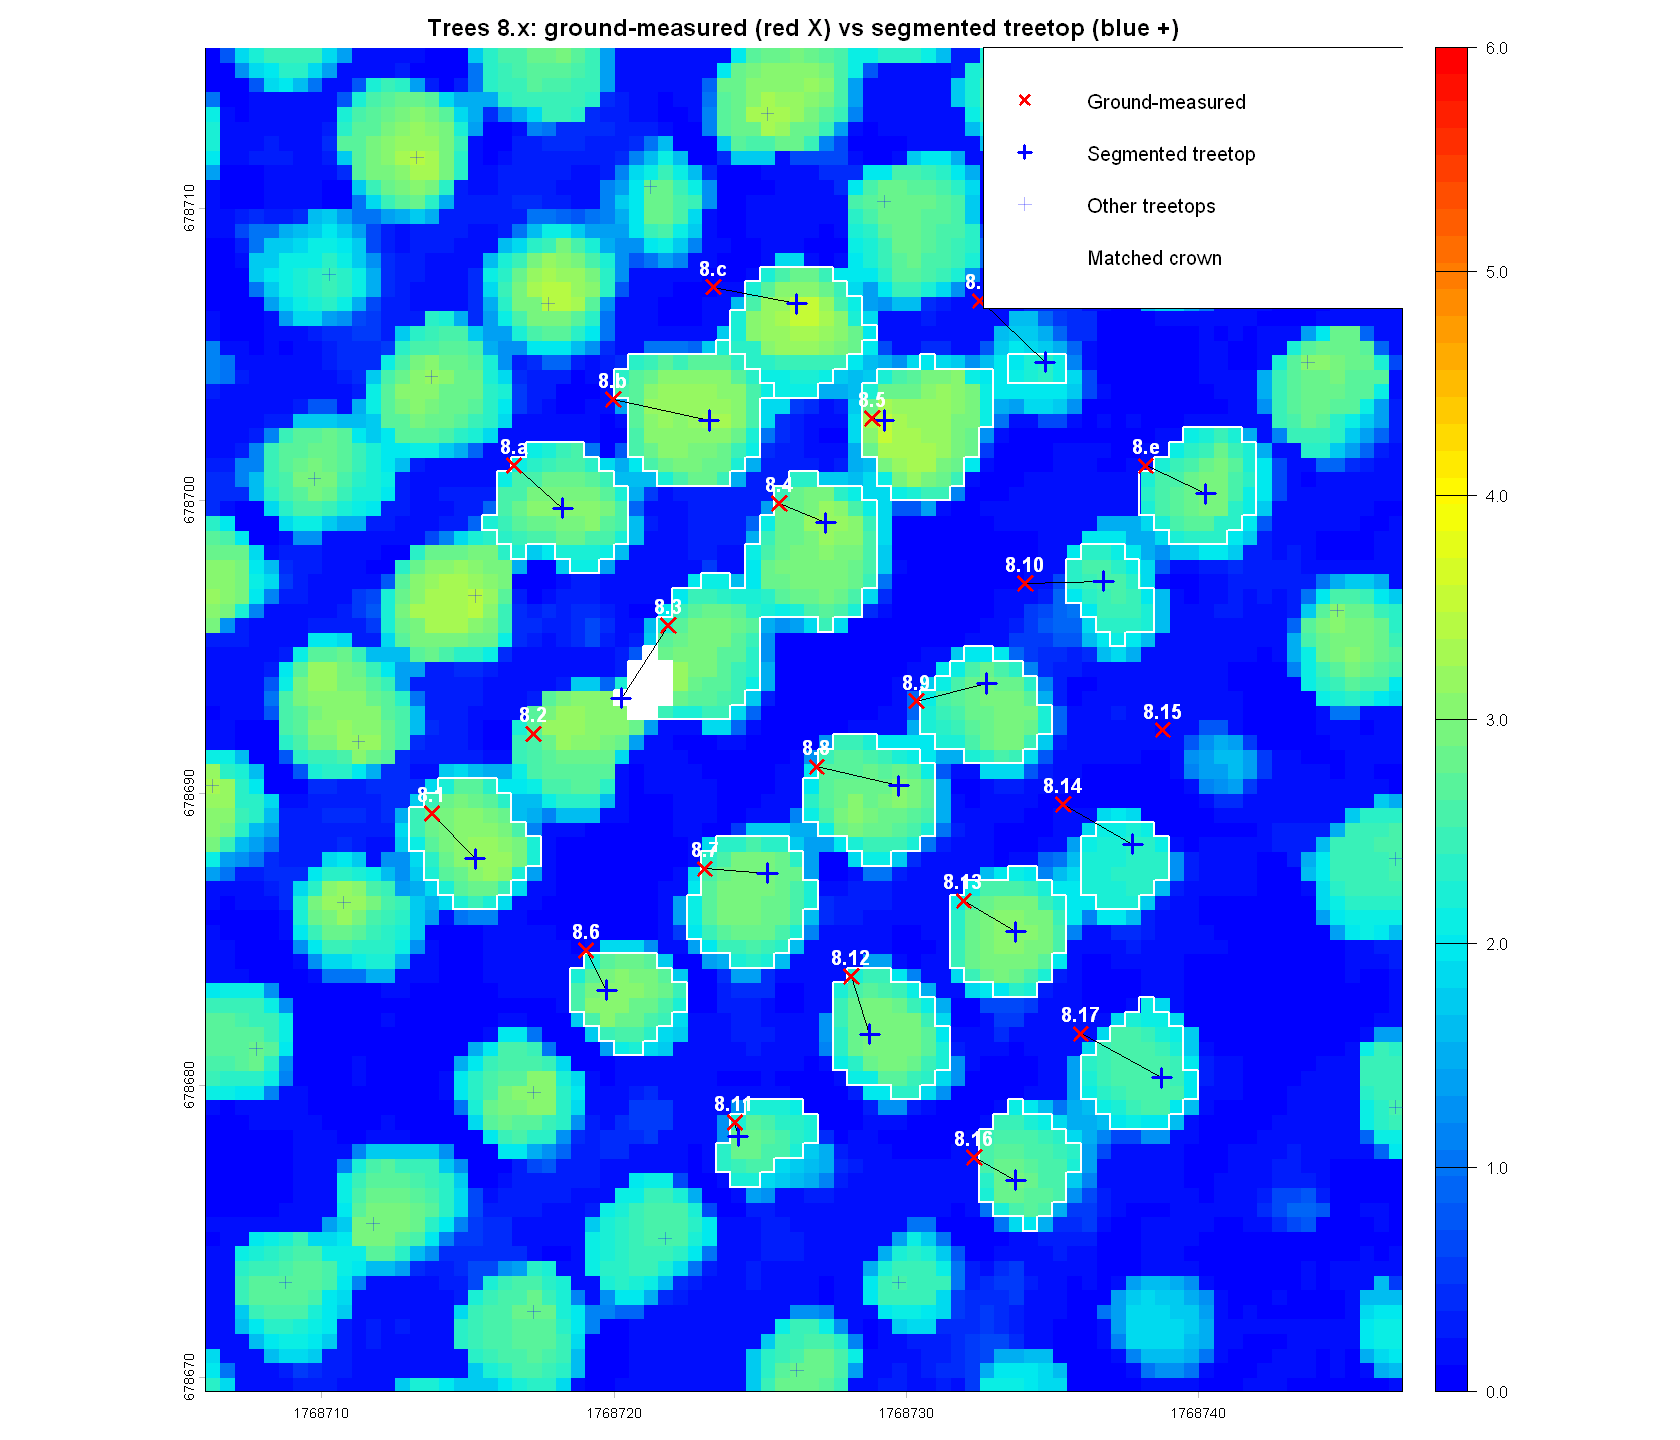

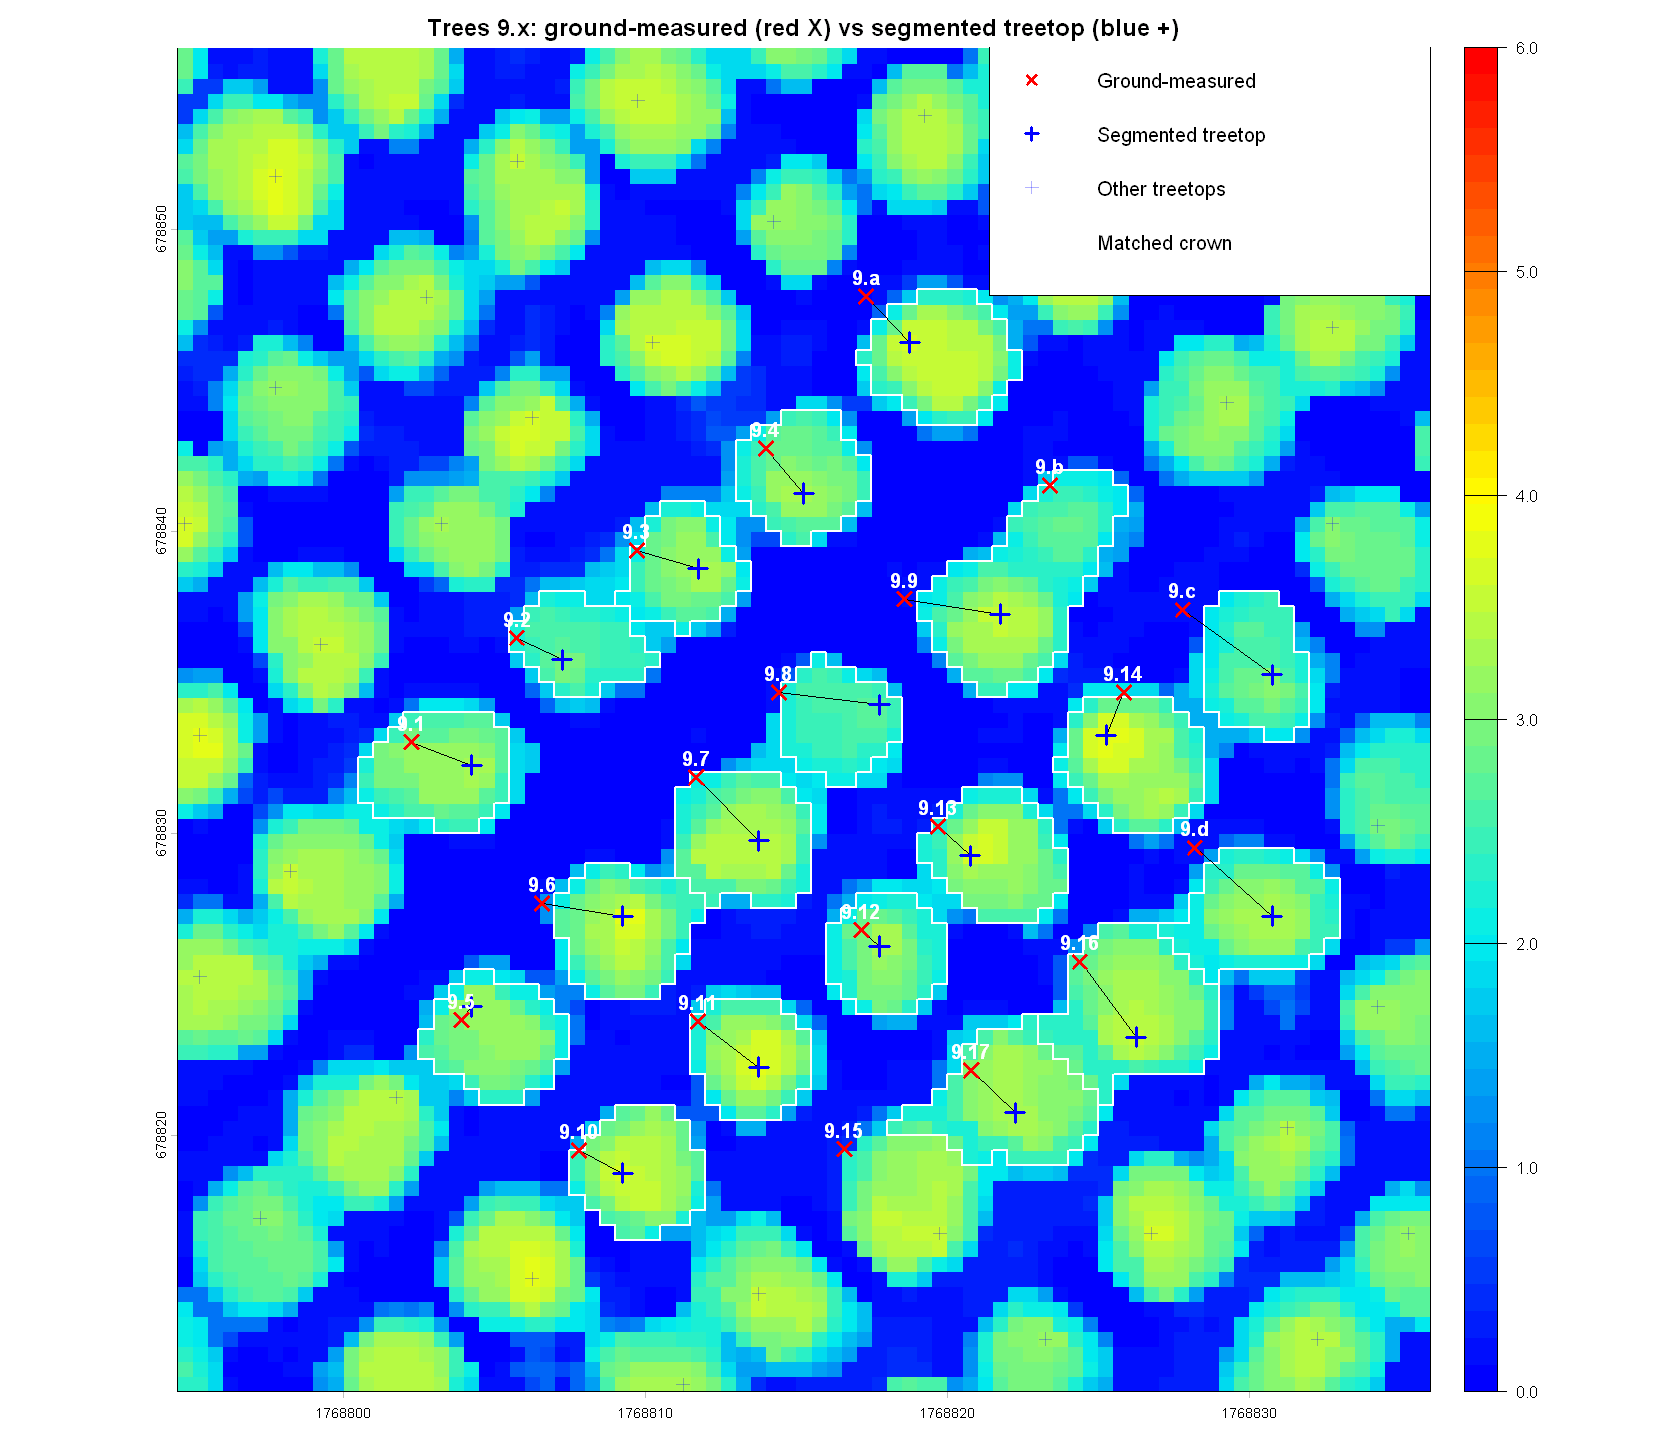

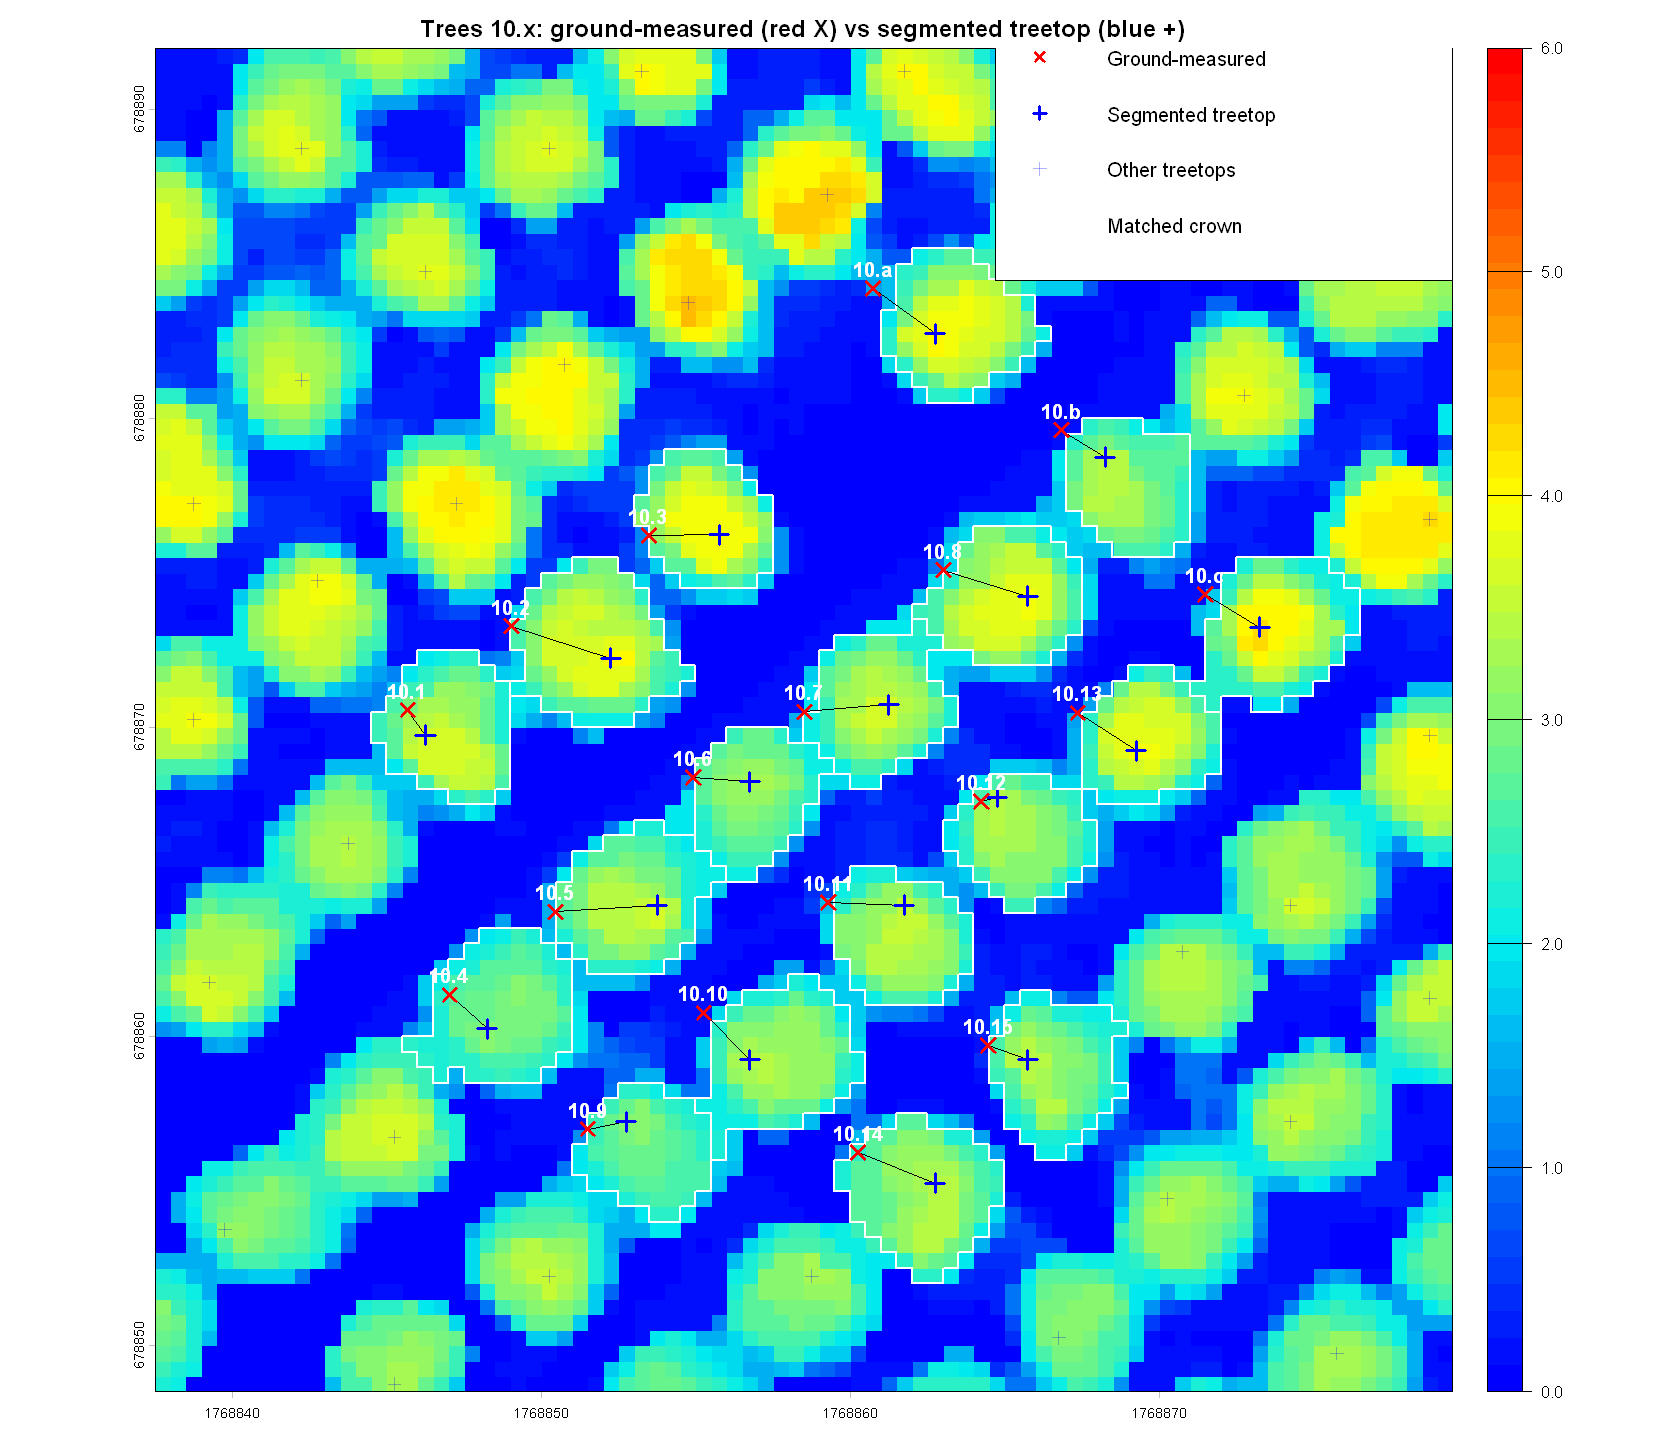

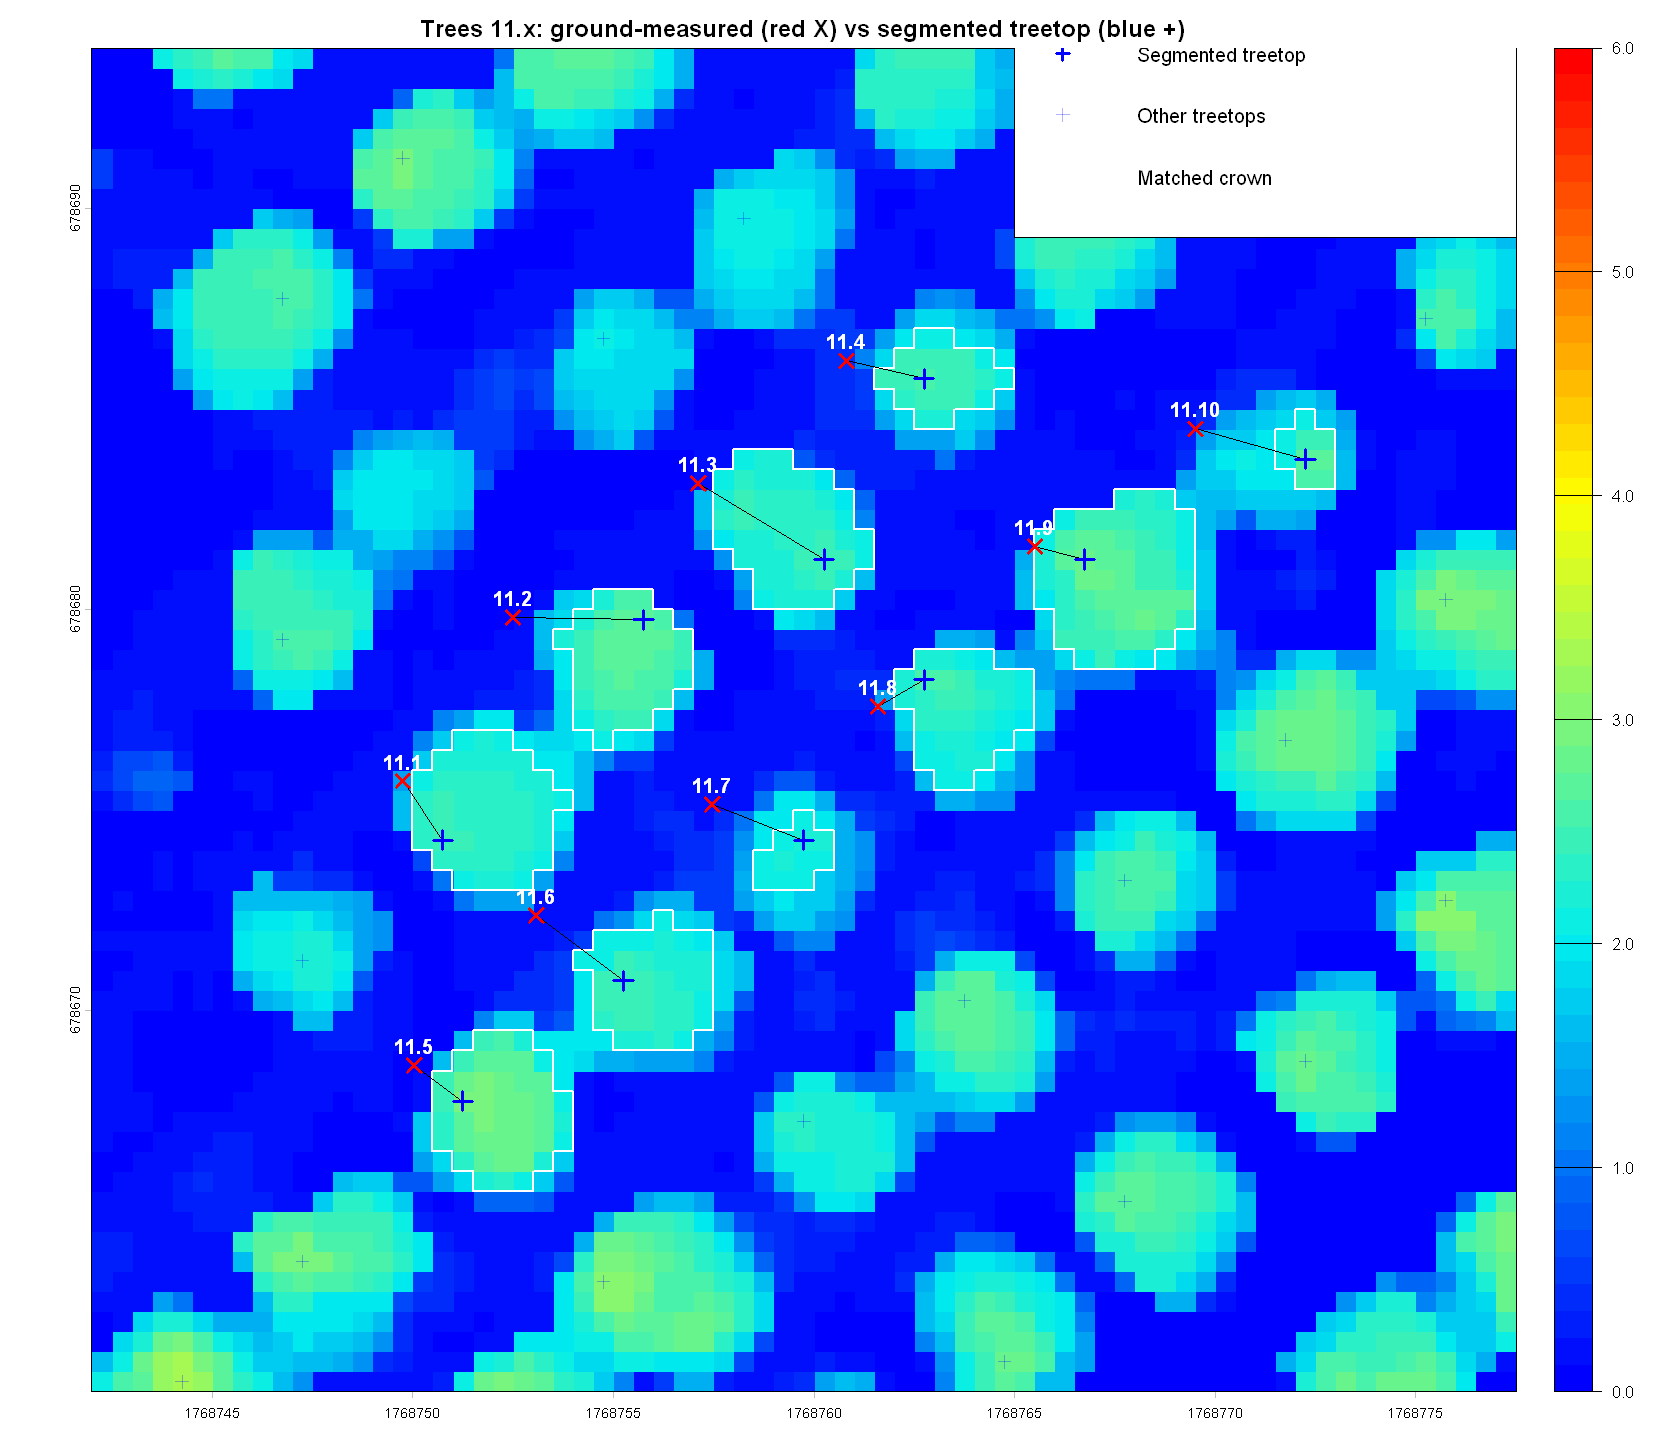

In [9]:
plot_label_group <- function(prefix, pad = 8) {
  g <- comparison[!is.na(comparison$gt_x) & grepl(paste0("^", prefix, "\\."), comparison$label), ]
  if (!nrow(g)) return(invisible(NULL))

  e  <- ext(min(g$gt_x) - pad, max(g$gt_x) + pad, min(g$gt_y) - pad, max(g$gt_y) + pad)
  bb <- st_bbox(c(xmin = xmin(e), xmax = xmax(e), ymin = ymin(e), ymax = ymax(e)), crs = st_crs(ttops))

  options(repr.plot.width = 14, repr.plot.height = 12)
  plot(crop(chm_smooth, e), col = height.colors(50), range = c(0, 6),
       main = sprintf("Trees %s.x: ground-measured (red X) vs segmented treetop (blue +)", prefix))

  tt_w <- ttops[st_intersects(ttops, st_as_sfc(bb), sparse = FALSE)[, 1], ]
  plot(st_geometry(tt_w), add = TRUE, pch = 3, col = adjustcolor("blue", 0.3))
  plot(st_geometry(polys[polys$treeID %in% g$seg_treeID, ]), border = "white", col = NA, lwd = 2, add = TRUE)

  m <- g[g$matched, ]
  segments(m$gt_x, m$gt_y, m$seg_x, m$seg_y, col = "black", lwd = 1.5)
  points(m$seg_x, m$seg_y, pch = 3, col = "blue", lwd = 3, cex = 1.5)
  points(g$gt_x, g$gt_y, pch = 4, col = "red", lwd = 3, cex = 1.5)
  text(g$gt_x, g$gt_y, g$label, pos = 3, col = "white", cex = 1, font = 2)

  legend("topright", legend = c("Ground-measured", "Segmented treetop", "Other treetops", "Matched crown"),
         pch = c(4, 3, 3, NA), col = c("red", "blue", adjustcolor("blue", 0.3), NA),
         lty = c(NA, NA, NA, 1), lwd = c(3, 3, 1, 2), bg = "white")
}

prefixes <- sort(unique(as.numeric(sub("\\..*", "", grep("^[0-9]+\\.", comparison$label, value = TRUE)))))
for (p in prefixes) plot_label_group(p)

## 8. NEXT STEPS
   1. troubleshoot areas that did not match, set maximum height as well to avoid wind turbines reading as height
   2. add in WT app comparisons
   3. verify biomass calculations
   4. add in visuals for biomass
   5. perform stastical analyses
   6. build into presentation format
   7. get backpack data and perform the same


## 9. Export

In [10]:
tree_data <- data.frame(treeID = ttops$treeID, x = st_coordinates(ttops)[, "X"],
                        y = st_coordinates(ttops)[, "Y"], height_m = ttops$height) |>
  left_join(st_drop_geometry(polys) |> select(treeID, crown_area_m2 = area_m2, crown_diam_m = diam_m, flag), by = "treeID")
write.csv(tree_data, file.path(out_dir, "tree_heights.csv"), row.names = FALSE)
st_write(polys, file.path(out_dir, "crowns.gpkg"), delete_dsn = TRUE, quiet = TRUE)
st_write(ttops, file.path(out_dir, "treetops.gpkg"), delete_dsn = TRUE, quiet = TRUE)
cat("Saved to", normalizePath(out_dir), "\n")

Saved to C:\Users\davisk10\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\GitHub_Repository\Biomass_Monitoring_Research\outputs\Bartleson Tree Segmentation\dalponte_0.5m 
